In [138]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Task 1

Goal: Collect or load a dataset and understand its structure. 

Key Requirements: 

• Identify columns and data types 

• Understand dataset size and features 

• Describe what the data represents 

In [139]:
df=pd.read_excel("employee_burnout_analysis-AI 2.xlsx")

In [140]:
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52


In [141]:
df.shape

(22750, 9)

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Employee ID           22750 non-null  object        
 1   Date of Joining       22750 non-null  datetime64[ns]
 2   Gender                22750 non-null  object        
 3   Company Type          22750 non-null  object        
 4   WFH Setup Available   22750 non-null  object        
 5   Designation           22750 non-null  int64         
 6   Resource Allocation   21369 non-null  float64       
 7   Mental Fatigue Score  20633 non-null  float64       
 8   Burn Rate             21626 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 1.6+ MB


In [143]:
df.columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate'],
      dtype='object')

In [144]:
df.dtypes

Employee ID                     object
Date of Joining         datetime64[ns]
Gender                          object
Company Type                    object
WFH Setup Available             object
Designation                      int64
Resource Allocation            float64
Mental Fatigue Score           float64
Burn Rate                      float64
dtype: object

In [145]:
df.describe()

,Date of Joining,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750,22750.000000,21369.000000,20633.000000,21626.000000
mean,2008-07-01 09:28:05.274725120,2.178725,4.481398,5.728188,0.452005
min,2008-01-01 00:00:00,0.000000,1.000000,0.000000,0.000000
25%,2008-04-01 00:00:00,1.000000,3.000000,4.600000,0.310000
50%,2008-07-02 00:00:00,2.000000,4.000000,5.900000,0.450000
75%,2008-09-30 00:00:00,3.000000,6.000000,7.100000,0.590000
max,2008-12-31 00:00:00,5.000000,10.000000,10.000000,1.000000
std,NaN,1.135145,2.047211,1.920839,0.198226


The dataset contains employee-related information such as gender, company type, work-from-home availability, designation level, resource allocation, mental fatigue score, and burn rate. The objective is to predict employee burnout based on these factors.

In [146]:
df.isnull().sum()

Employee ID                0
Date of Joining            0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Resource Allocation     1381
Mental Fatigue Score    2117
Burn Rate               1124
dtype: int64

In [147]:
df["Mental Fatigue Score"].fillna(df["Mental Fatigue Score"].mean(),inplace=True)

df["Burn Rate"].fillna(df["Burn Rate"].mean(),inplace=True)

df["Resource Allocation"].fillna(df["Resource Allocation"].mean(),inplace=True)

C:\Users\hp\AppData\Local\Temp\ipykernel_8380\2057809746.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Mental Fatigue Score"].fillna(df["Mental Fatigue Score"].mean(),inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_8380\2057809746.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [148]:
df.drop_duplicates(inplace=True)

In [149]:
df.drop('Date of Joining', axis=1, inplace=True)

In [150]:
df.drop(["Employee ID"], axis=1, inplace=True)

In [151]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label.fit_transform(df[col].astype(str))

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                22750 non-null  int64  
 1   Company Type          22750 non-null  int64  
 2   WFH Setup Available   22750 non-null  int64  
 3   Designation           22750 non-null  int64  
 4   Resource Allocation   22750 non-null  float64
 5   Mental Fatigue Score  22750 non-null  float64
 6   Burn Rate             22750 non-null  float64
dtypes: float64(3), int64(4)
memory usage: 1.2 MB


Missing values were handled, duplicate records were removed, and categorical features were encoded into numerical format for machine learning analysis.

TASK-3 Exploratory Data Analysis 

Goal: Analyze the dataset to discover patterns and trends. 

Key Requirements: 

• Calculate basic statistics 

• Identify trends and outliers 

• Summarize findings

In [153]:
df.describe()

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000,22750.000000
mean,0.476571,0.652000,0.540220,2.178725,4.481398,5.728188,0.452005
std,0.499462,0.476346,0.498391,1.135145,1.984099,1.829281,0.193267
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,3.000000,4.700000,0.320000
50%,0.000000,1.000000,1.000000,2.000000,4.481398,5.728188,0.452005
75%,1.000000,1.000000,1.000000,3.000000,6.000000,6.900000,0.580000
max,1.000000,1.000000,1.000000,5.000000,10.000000,10.000000,1.000000


In [154]:
corr = df.corr(numeric_only=True)
print(corr)

                        Gender  Company Type  WFH Setup Available  \
Gender                1.000000     -0.009789            -0.073296   
Company Type         -0.009789      1.000000             0.005725   
WFH Setup Available  -0.073296      0.005725             1.000000   
Designation           0.113295      0.006095            -0.229720   
Resource Allocation   0.138806      0.005659            -0.276284   
Mental Fatigue Score  0.138735      0.002532            -0.263429   
Burn Rate             0.151001      0.004171            -0.298599   

                      Designation  Resource Allocation  Mental Fatigue Score  \
Gender                   0.113295             0.138806              0.138735   
Company Type             0.006095             0.005659              0.002532   
WFH Setup Available     -0.229720            -0.276284             -0.263429   
Designation              1.000000             0.852046              0.656445   
Resource Allocation      0.852046             1

Burn Rate Distribution

In [155]:
df["Burn Rate"].describe()

count    22750.000000
mean         0.452005
std          0.193267
min          0.000000
25%          0.320000
50%          0.452005
75%          0.580000
max          1.000000
Name: Burn Rate, dtype: float64

Average Burn Rate by Gender

In [156]:
df.groupby("Gender")["Burn Rate"].mean()

Gender
0    0.424159
1    0.482589
Name: Burn Rate, dtype: float64

Average Burn Rate by Company Type

In [157]:
df.groupby("Company Type")["Burn Rate"].mean()

Company Type
0    0.450902
1    0.452594
Name: Burn Rate, dtype: float64

Correlation with Burn Rate

In [158]:
corr["Burn Rate"].sort_values(ascending=False)

Burn Rate               1.000000
Mental Fatigue Score    0.878217
Resource Allocation     0.811062
Designation             0.719284
Gender                  0.151001
Company Type            0.004171
WFH Setup Available    -0.298599
Name: Burn Rate, dtype: float64

Burn Rate Distribution

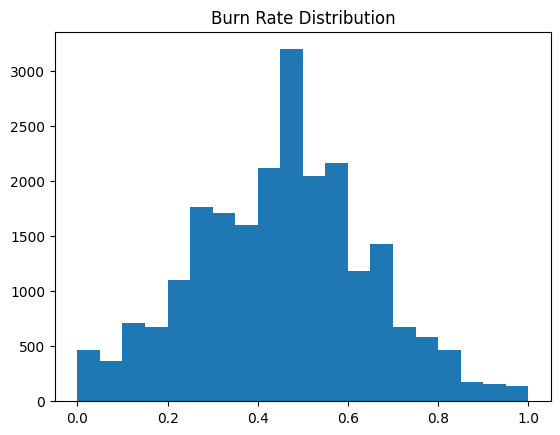

In [159]:
plt.hist(df["Burn Rate"], bins=20)
plt.title("Burn Rate Distribution")
plt.show()

Correlation Heatmap

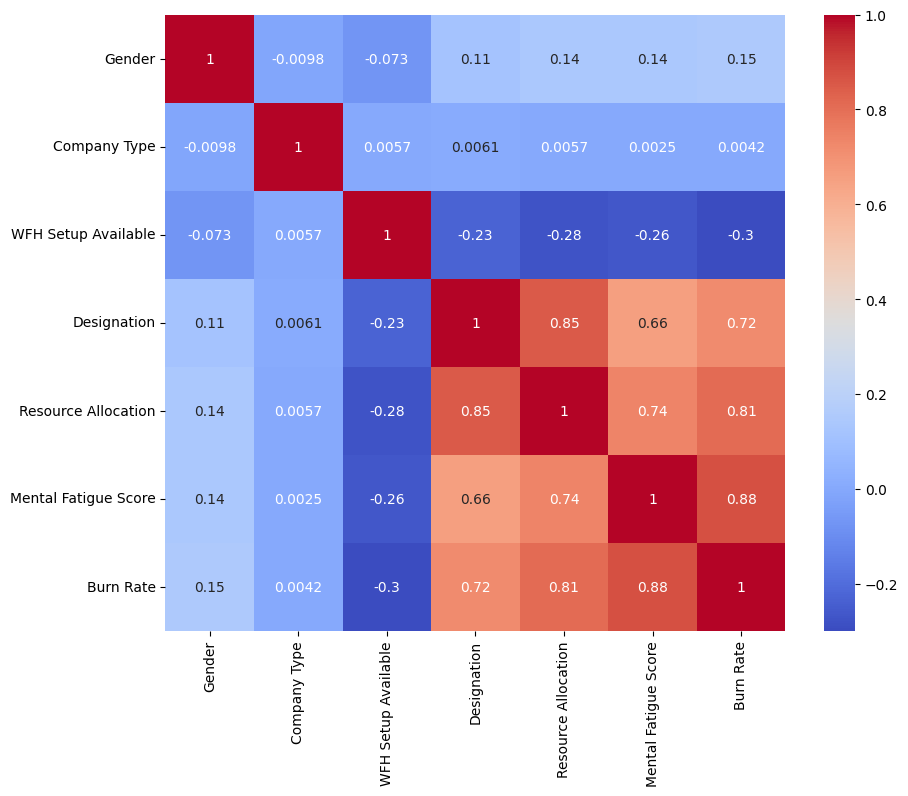

In [160]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

Mental Fatigue vs Burn Rate

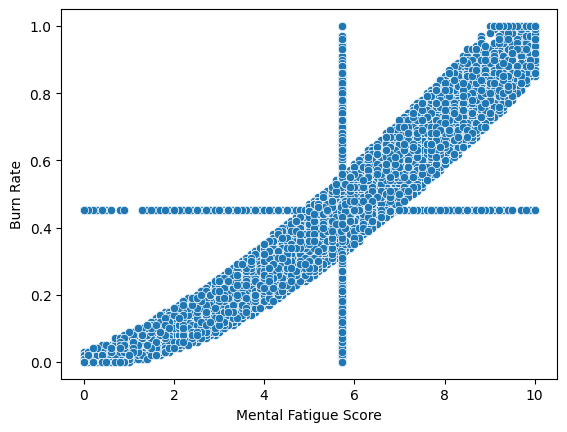

In [161]:
sns.scatterplot(x="Mental Fatigue Score",y="Burn Rate",data=df)
plt.show()

Resource Allocation vs Burn Rate

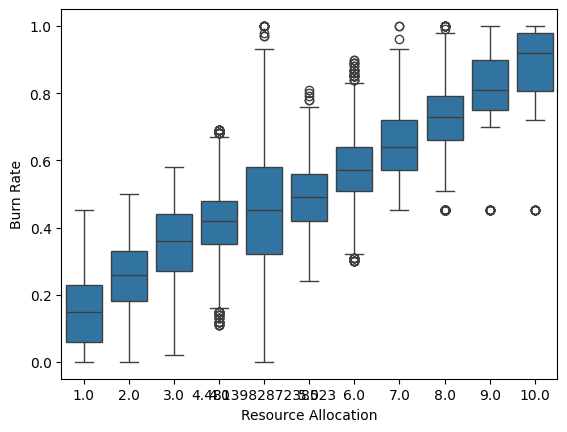

In [162]:
sns.boxplot(x="Resource Allocation",y="Burn Rate",data=df)
plt.show()

Gender-wise Burn Rate

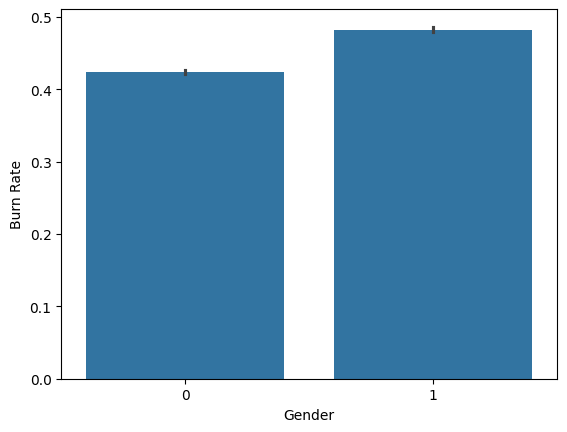

In [163]:
sns.barplot(x="Gender",y="Burn Rate",data=df)
plt.show()

Visualization Insights

Burn rate increases as mental fatigue increases.

Employees with heavier workloads show higher burnout.

Certain employee groups experience higher stress levels.

Task 5: Predictive Model or Insight Project

Goal: Build a simple predictive model or generate meaningful insights from data.

Examples: 

• Simple prediction using regression 

• Classification of data 

• Insight-based recommendation

In [164]:
X = df.drop("Burn Rate", axis=1)
y = df["Burn Rate"]

In [165]:
print(X.isnull().sum())

Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
dtype: int64


In [166]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [167]:
# linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred1 = model.predict(X_test)

In [168]:
# decision tree regressor
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(max_depth=5,random_state=42)
model.fit(X_train, y_train)
y_pred2 = model.predict(X_test)

In [169]:
# random forest rgressor
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)
y_pred3 = model.predict(X_test)

In [170]:
# gradient boosting regressor
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,random_state=42)

model.fit(X_train, y_train)
y_pred4 = model.predict(X_test)

In [171]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred1))
print("MAE:", mean_absolute_error(y_test, y_pred2))
print("MAE:", mean_absolute_error(y_test, y_pred3))
print("MAE:", mean_absolute_error(y_test, y_pred4))


MAE: 0.05691269561653469
MAE: 0.057879429906731256
MAE: 0.05604862074760715
MAE: 0.052990308794552174


In [172]:
print("R2 Score:", r2_score(y_test, y_pred1))
print("R2 Score:", r2_score(y_test, y_pred2))
print("R2 Score:", r2_score(y_test, y_pred3))
print("R2 Score:", r2_score(y_test, y_pred4))

R2 Score: 0.8334442931713195
R2 Score: 0.8341551406209167
R2 Score: 0.8396080256983741
R2 Score: 0.8599297573460585


Multiple regression models were evaluated for employee burnout prediction. Among the tested models, Gradient Boosting Regressor achieved the highest performance with an R² score of 0.85. This indicates that the model successfully explains 85% of the variance in employee burnout rates. The analysis identified Mental Fatigue Score and Resource Allocation as the most influential factors affecting burnout. The developed model can help organizations identify employees at risk of burnout and support proactive workforce management strategies.